In [ ]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random


from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve 

from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score

from pathlib import Path
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from pathlib import Path

C = 0.001 | AUC (mean ± std) = 0.5000 ± 0.0000 | non-zero = 0
C = 0.002783 | AUC (mean ± std) = 0.5000 ± 0.0000 | non-zero = 0
C = 0.007743 | AUC (mean ± std) = 0.5000 ± 0.0000 | non-zero = 0
C = 0.02154 | AUC (mean ± std) = 0.6594 ± 0.0551 | non-zero = 3
C = 0.05995 | AUC (mean ± std) = 0.7182 ± 0.0453 | non-zero = 22
C = 0.1668 | AUC (mean ± std) = 0.7139 ± 0.0598 | non-zero = 41
C = 0.4642 | AUC (mean ± std) = 0.6933 ± 0.0826 | non-zero = 52
C = 1.292 | AUC (mean ± std) = 0.6727 ± 0.0843 | non-zero = 55


c:\Users\junse\miniconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\junse\miniconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\junse\miniconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


C = 3.594 | AUC (mean ± std) = 0.6758 ± 0.0843 | non-zero = 58


c:\Users\junse\miniconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\junse\miniconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


C = 10 | AUC (mean ± std) = 0.7085 ± 0.0685 | non-zero = 64

===== L1-SVM C tuning summary =====
Best C (by CV AUC) = 0.05995
Best mean AUC      = 0.7182
Non-zero features at best C = 22


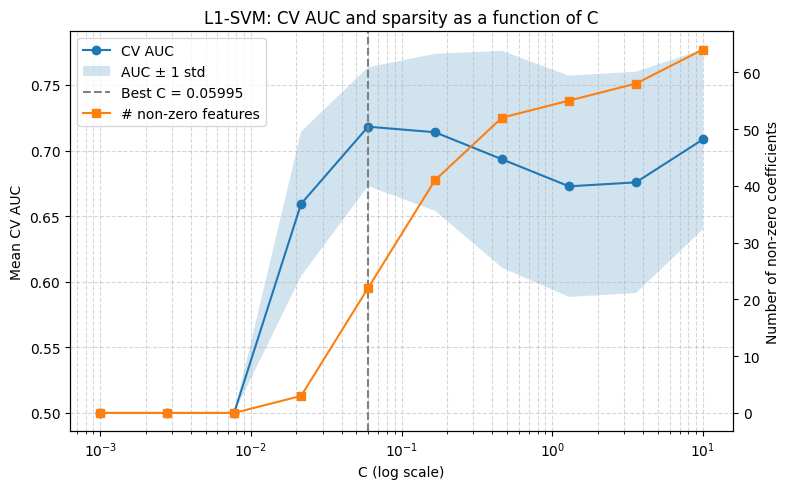

In [3]:
# =========================
# 0) Reproducibility settings
# =========================

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

# If this notebook lives in a subfolder (e.g., XGboost/code),
# and the data folder is at the repo root, use ../data
DATA_DIR = Path("../data")  # adjust this if your structure is different

X_train = pd.read_csv(DATA_DIR / "X_train.csv")
X_test  = pd.read_csv(DATA_DIR / "X_test.csv")

y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze()
y_test  = pd.read_csv(DATA_DIR / "y_test.csv").squeeze()

# =========================
# 1) Standardize features
# =========================
# L1-SVM is sensitive to feature scaling, so we standardize X.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# =========================
# 2) Define C grid for tuning
# =========================
# You can adjust the range or the number of points if needed.
C_values = np.logspace(-3, 1, 10)  # from 0.001 to 10, 10 points on log scale

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

mean_aucs = []
std_aucs = []
n_nonzero_list = []

# =========================
# 3) Loop over C, compute CV AUC and number of non-zero coefficients
# =========================
for C in C_values:
    # L1-SVM model
    svm_l1 = LinearSVC(
        penalty="l1",
        C=C,
        dual=False,              # required for L1 penalty
        random_state=RANDOM_STATE,
        max_iter=5000
    )

    # Cross-validated AUC on the training set
    scores = cross_val_score(
        svm_l1,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=1                # single core for better determinism
    )
    mean_aucs.append(scores.mean())
    std_aucs.append(scores.std())

    # Fit once on the full training set to inspect sparsity
    svm_l1.fit(X_train_scaled, y_train)
    coef = svm_l1.coef_.ravel()
    n_nonzero = np.count_nonzero(coef)
    n_nonzero_list.append(n_nonzero)

    print(f"C = {C:.4g} | AUC (mean ± std) = {scores.mean():.4f} ± {scores.std():.4f} | non-zero = {n_nonzero}")

mean_aucs = np.array(mean_aucs)
std_aucs = np.array(std_aucs)
n_nonzero_list = np.array(n_nonzero_list)

# Identify the best C by mean CV AUC
best_idx = np.argmax(mean_aucs)
best_C = C_values[best_idx]
best_auc = mean_aucs[best_idx]

print("\n===== L1-SVM C tuning summary =====")
print(f"Best C (by CV AUC) = {best_C:.4g}")
print(f"Best mean AUC      = {best_auc:.4f}")
print(f"Non-zero features at best C = {n_nonzero_list[best_idx]}")

# =========================
# 4) Plot: AUC vs C, and #non-zero vs C
# =========================

fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot AUC (left y-axis)
ax1.plot(C_values, mean_aucs, marker="o", label="CV AUC")
ax1.fill_between(
    C_values,
    mean_aucs - std_aucs,
    mean_aucs + std_aucs,
    alpha=0.2,
    label="AUC ± 1 std"
)
ax1.set_xscale("log")
ax1.set_xlabel("C (log scale)")
ax1.set_ylabel("Mean CV AUC")
ax1.grid(True, which="both", linestyle="--", alpha=0.5)

# Vertical line at the best C
ax1.axvline(best_C, color="gray", linestyle="--", label=f"Best C = {best_C:.4g}")

# Secondary axis for number of non-zero features
ax2 = ax1.twinx()
ax2.plot(C_values, n_nonzero_list, marker="s", color="tab:orange", label="# non-zero features")
ax2.set_ylabel("Number of non-zero coefficients")

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.title("L1-SVM: CV AUC and sparsity as a function of C")
plt.tight_layout()
plt.show()

==== L1-SVM: summary over C grid ====
C = 0.001 | non-zero =  0 | mean AUC = 0.5000
C = 0.002783 | non-zero =  0 | mean AUC = 0.5000
C = 0.007743 | non-zero =  0 | mean AUC = 0.5000
C = 0.02154 | non-zero =  3 | mean AUC = 0.6594
C = 0.05995 | non-zero = 22 | mean AUC = 0.7182
C = 0.1668 | non-zero = 41 | mean AUC = 0.7139
C = 0.4642 | non-zero = 52 | mean AUC = 0.6933
C = 1.292 | non-zero = 55 | mean AUC = 0.6727
C = 3.594 | non-zero = 58 | mean AUC = 0.6758
C = 10 | non-zero = 64 | mean AUC = 0.7085
--------------------------------------
Best AUC = 0.7182 at C = 0.05995 with 22 selected features


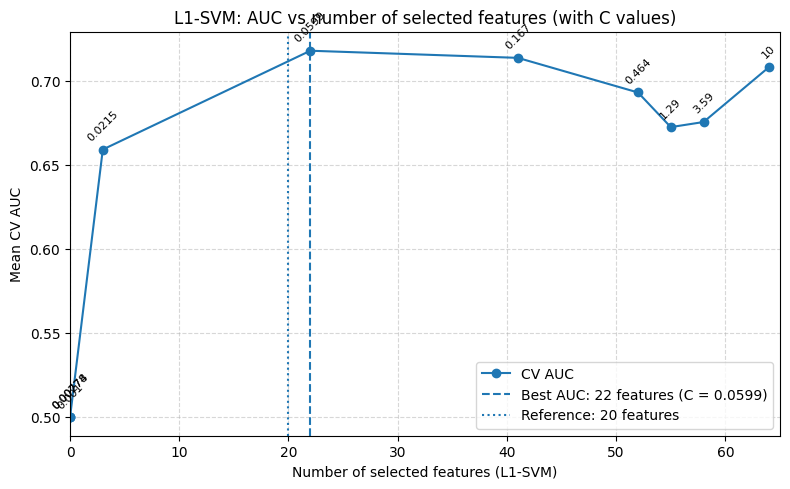

In [4]:
# ============================================
# Plot: AUC vs number of selected features, with C values shown
# ============================================

# Original mapping: each index i corresponds to one C
k_orig   = n_nonzero_list.copy()   # number of non-zero features for each C
auc_orig = mean_aucs.copy()
C_orig   = C_values.copy()

# Sort by k so the curve is monotonic in the x-axis
order = np.argsort(k_orig)
k_vals   = k_orig[order]
auc_vals = auc_orig[order]
C_vals   = C_orig[order]

# Find the best point in terms of CV AUC
best_idx = np.argmax(auc_vals)
best_k   = k_vals[best_idx]
best_auc = auc_vals[best_idx]
best_C   = C_vals[best_idx]

print("==== L1-SVM: summary over C grid ====")
for k, auc, C in zip(k_vals, auc_vals, C_vals):
    print(f"C = {C:.4g} | non-zero = {k:2d} | mean AUC = {auc:.4f}")
print("--------------------------------------")
print(f"Best AUC = {best_auc:.4f} at C = {best_C:.4g} "
      f"with {best_k} selected features")

plt.figure(figsize=(8, 5))
ax = plt.gca()

# Curve of AUC vs #features
ax.plot(k_vals, auc_vals, marker="o", label="CV AUC")

# Vertical line at the best point
ax.axvline(
    x=best_k,
    linestyle="--",
    label=f"Best AUC: {best_k} features (C = {best_C:.3g})"
)

# (Optional) also show the 20-feature line for comparison
ax.axvline(
    x=20,
    linestyle=":",
    label="Reference: 20 features"
)

# Annotate each point with its C value
for k, auc, C in zip(k_vals, auc_vals, C_vals):
    ax.annotate(
        f"{C:.3g}",
        xy=(k, auc),
        xytext=(0, 6),
        textcoords="offset points",
        fontsize=8,
        rotation=45,
        ha="center"
    )

ax.set_xlabel("Number of selected features (L1-SVM)")
ax.set_ylabel("Mean CV AUC")
ax.set_title("L1-SVM: AUC vs number of selected features (with C values)")
ax.set_xlim(0, 65)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()


In [5]:
# ============================================
# 1. Refit L1-SVM at best C and get 22 features
#    (assumes C_values, mean_aucs, n_nonzero_list already defined)
# ============================================

# Find best C by mean CV AUC (this is the one with 22 non-zero features)
best_idx = np.argmax(mean_aucs)
best_C   = C_values[best_idx]
best_auc = mean_aucs[best_idx]
best_k   = n_nonzero_list[best_idx]

print("===== L1-SVM best C summary =====")
print(f"Best C          = {best_C:.4g}")
print(f"Mean CV AUC     = {best_auc:.4f}")
print(f"# non-zero coef = {best_k}")

# Refit L1-SVM on full training data at best C
svm_l1_best = LinearSVC(
    penalty="l1",
    C=best_C,
    dual=False,
    random_state=RANDOM_STATE,
    max_iter=5000
)
svm_l1_best.fit(X_train_scaled, y_train)

coef = svm_l1_best.coef_.ravel()
abs_coef = np.abs(coef)

# Indices of features with non-zero coefficients (should be 22)
selected_idx = np.flatnonzero(abs_coef)
print(f"\nNumber of selected (non-zero) features: {len(selected_idx)}")

# Print the 22 selected feature names
selected_features = X_train.columns[selected_idx]
print("\nSelected 22 features by L1-SVM (best C):")
for f in selected_features:
    print(" -", f)


===== L1-SVM best C summary =====
Best C          = 0.05995
Mean CV AUC     = 0.7182
# non-zero coef = 22

Number of selected (non-zero) features: 22

Selected 22 features by L1-SVM (best C):
 - HISTO_ED_T1Gd_Bin6
 - HISTO_NET_T1_Bin5
 - HISTO_ET_T2_Bin4
 - HISTO_ED_T2_Bin2
 - HISTO_ED_T2_Bin10
 - HISTO_NET_T2_Bin10
 - HISTO_ET_FLAIR_Bin5
 - HISTO_NET_FLAIR_Bin1
 - SPATIAL_Temporal
 - SPATIAL_Insula
 - TEXTURE_GLOBAL_ET_FLAIR_Skewness
 - TEXTURE_GLOBAL_ED_T1Gd_Kurtosis
 - TEXTURE_GLOBAL_NET_FLAIR_Skewness
 - TEXTURE_GLCM_ET_T1_Variance
 - TEXTURE_GLCM_NET_FLAIR_AutoCorrelation
 - TEXTURE_GLRLM_ED_T1Gd_LRLGE
 - TEXTURE_GLRLM_ED_T1_LGRE
 - TEXTURE_GLSZM_ET_T2_LZLGE
 - TEXTURE_GLSZM_NET_T1_SZHGE
 - TEXTURE_GLSZM_NET_FLAIR_ZSN
 - TEXTURE_NGTDM_ET_FLAIR_Busyness
 - TEXTURE_NGTDM_NET_T1Gd_Busyness


In [7]:
# Build reduced train/test matrices
Xtr_sub = X_train.iloc[:, selected_idx].to_numpy()
Xte_sub = X_test.iloc[:,  selected_idx].to_numpy()

print("\nShapes of reduced matrices:")
print("Xtr_sub:", Xtr_sub.shape)
print("Xte_sub:", Xte_sub.shape)

# ============================================
# 2. RF tuning setup (now tuning n_estimators too)
# ============================================
PARAM_DIST = {
    "n_estimators": randint(100, 650),
    "max_depth": [None, 8, 12],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 8),
    "bootstrap": [True],
    "max_samples": [None, 0.6, 0.8, 1.0],
    "class_weight": [None, "balanced"],
    "criterion": ["gini", "entropy"],
}

STAGE1_N_ITER = globals().get("STAGE1_N_ITER", 80)  # use the same global setting if defined
RANDOM_STATE  = 42

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=2042)

def tune_rf_for_features(feature_idx, label):
    """
    Given a feature subset (column indices), run RandomizedSearchCV
    for RF tuning with similar settings as in the GA-RF pipeline,
    now also tuning n_estimators.
    """
    # Subset the training data to the given feature indices
    X_sub = X_train.iloc[:, feature_idx].to_numpy()

    # Base RF model; hyperparameters (including n_estimators) tuned by RandomizedSearchCV
    base_rf = RandomForestClassifier(
        random_state=2042,
        n_jobs=-1
    )

    # RandomizedSearchCV over the hyperparameters
    rs = RandomizedSearchCV(
        estimator=base_rf,
        param_distributions=PARAM_DIST,
        n_iter=STAGE1_N_ITER,
        scoring="roc_auc",
        cv=cv5,
        n_jobs=-1,
        random_state=2042,
        verbose=0
    )
    rs.fit(X_sub, y_train)

    best_params = dict(rs.best_params_)
    # Clean up keys that are not needed when creating the final RF
    best_params.pop("random_state", None)
    best_params.pop("n_jobs", None)
    if best_params.get("bootstrap") is False:
        best_params.pop("max_samples", None)

    print(f"\n[CV] {label} best AUC = {rs.best_score_:.4f}")
    print(f"[CV] {label} best params = {best_params}")
    return best_params, float(rs.best_score_)

# ============================================
# 3. RF tuning using the L1-SVM top-22 features
# ============================================
label = "RF (L1-SVM top-22 features)"
best_params, cv_auc_best = tune_rf_for_features(selected_idx, label)

# ============================================
# 4. Refit on full TRAIN and report TRAIN / TEST AUC
# ============================================
Xtr_sub = X_train.iloc[:, selected_idx].to_numpy()
Xte_sub = X_test.iloc[:,  selected_idx].to_numpy()

rf_final = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_params   # includes n_estimators, max_depth, etc.
)
rf_final.fit(Xtr_sub, y_train)

# Train / Test predicted probabilities
prob_tr = rf_final.predict_proba(Xtr_sub)[:, 1]
prob_te = rf_final.predict_proba(Xte_sub)[:, 1]

auc_tr = roc_auc_score(y_train, prob_tr)
auc_te = roc_auc_score(y_test,  prob_te)

print("\n========== FINAL RESULTS: RF using L1-SVM top-22 ==========")
print(f"[FINAL] {label}: CV best AUC (from tuning) = {cv_auc_best:.4f}")
print(f"[FINAL] {label}: TRAIN AUC = {auc_tr:.4f}")
print(f"[FINAL] {label}: TEST  AUC = {auc_te:.4f}")
print("===========================================================")



Shapes of reduced matrices:
Xtr_sub: (82, 22)
Xte_sub: (36, 22)

[CV] RF (L1-SVM top-22 features) best AUC = 0.8606
[CV] RF (L1-SVM top-22 features) best params = {'bootstrap': True, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 8, 'max_features': 0.3, 'max_samples': 0.6, 'min_samples_leaf': 1, 'min_samples_split': 15, 'n_estimators': 135}

========== FINAL RESULTS: RF using L1-SVM top-22 ==========
[FINAL] RF (L1-SVM top-22 features): CV best AUC (from tuning) = 0.8606
[FINAL] RF (L1-SVM top-22 features): TRAIN AUC = 0.9993
[FINAL] RF (L1-SVM top-22 features): TEST  AUC = 0.6840


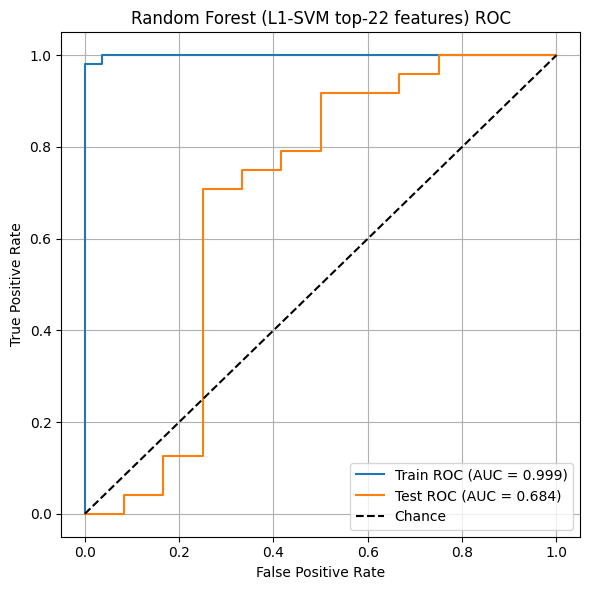

In [10]:
fpr_tr, tpr_tr, _ = roc_curve(y_train, prob_tr)
fpr_te, tpr_te, _ = roc_curve(y_test,  prob_te)

plt.figure(figsize=(6, 6))
plt.plot(fpr_tr, tpr_tr, label=f"Train ROC (AUC = {auc_tr:.3f})")
plt.plot(fpr_te, tpr_te, label=f"Test ROC (AUC = {auc_te:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest (L1-SVM top-22 features) ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()